In [35]:
# Updated paths to match your project structure
data_dir = '/Users/afrazrupak/CarProject_dev/car_project_dev/data/car_csv'
audi = f'{data_dir}/audi.csv'
benz = f'{data_dir}/benz.csv'
bmw = f'{data_dir}/bmw.csv'
byd = f'{data_dir}/byd.csv'
ford = f'{data_dir}/ford.csv'
honda = f'{data_dir}/honda.csv'
hyundai = f'{data_dir}/hyundai.csv'
kia = f'{data_dir}/kia.csv'
mazda = f'{data_dir}/mazda.csv'
mini = f'{data_dir}/mini.csv'
nissan = f'{data_dir}/nissan.csv'
toyota = f'{data_dir}/toyota.csv'
suzuki = f'{data_dir}/suzuki.csv'
tesla = f'{data_dir}/tesla.csv'
lexus = f'{data_dir}/lexus.csv'


In [36]:
import pandas as pd

# Read the CSV file using the existing variable 'audi' defined earlier
try:
	df = pd.read_csv(audi)
except FileNotFoundError:
	print(f"[warn] File not found: {audi}")
	print("Set 'audi' to the correct full path, e.g.: audi = '/full/path/to/audi.csv'")
	# Create an empty DataFrame to avoid downstream errors
	df = pd.DataFrame()

# Display the first few rows of the DataFrame (will be empty if file missing)
df.head()

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi
3,78,1,2010,c40f6b80d0cd6e,5,78/1/2010/c40f6b80d0cd6e.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi
4,78,1,2010,5d6ad69be2bd95,5,78/1/2010/5d6ad69be2bd95.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi


In [37]:
# Consolidate existing brand CSV path variables (already defined earlier) into a dict
brand_csv = {
    "audi": audi,
    "benz": benz,
    "bmw": bmw,
    "byd": byd,
    "ford": ford,
    "honda": honda,
    "hyundai": hyundai,
    "kia": kia,
    "mazda": mazda,
    "mini": mini,
    "nissan": nissan,
    "toyota": toyota,
    "suzuki": suzuki,
    "tesla": tesla,
    "lexus": lexus,
}

# Lazy loader: create a dict of DataFrames without overwriting existing df
def load_brand_frames(limit=None):
    frames = {}
    for i, (brand, path) in enumerate(brand_csv.items()):
        if limit is not None and i >= limit:
            break
        try:
            frames[brand] = pd.read_csv(path)
        except FileNotFoundError:
            print(f"[warn] Missing file: {path}")
        except Exception as e:
            print(f"[error] {brand}: {e}")
    return frames

# Build a combined dataframe (adds 'brand_source')
def build_combined(brands=None):
    to_use = brands if brands else list(brand_csv.keys())
    dfs = []
    for b in to_use:
        p = brand_csv.get(b)
        if not p:
            continue
        try:
            temp = pd.read_csv(p)
            temp["brand_source"] = b
            dfs.append(temp)
        except Exception as e:
            print(f"[skip] {b}: {e}")
    if not dfs:
        return None
    combined = pd.concat(dfs, axis=0, ignore_index=True)
    return combined



In [38]:
# Example (commented out to avoid heavy read unless you need it):
all_brands_df = build_combined()
all_brands_df.head()

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names,brand_source
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
3,78,1,2010,c40f6b80d0cd6e,5,78/1/2010/c40f6b80d0cd6e.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
4,78,1,2010,5d6ad69be2bd95,5,78/1/2010/5d6ad69be2bd95.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi


In [39]:
all_brands_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9824 entries, 0 to 9823
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   make_id        9824 non-null   int64  
 1   model_id       9824 non-null   int64  
 2   year           9824 non-null   object 
 3   image_name     9824 non-null   object 
 4   angle_no       9824 non-null   int64  
 5   image_path     9824 non-null   object 
 6   angle_side     9824 non-null   object 
 7   model_names    9824 non-null   object 
 8   maximum_speed  9824 non-null   float64
 9   displacement   9824 non-null   float64
 10  door_number    9824 non-null   float64
 11  seat_number    9824 non-null   float64
 12  type_id        9824 non-null   int64  
 13  car_type       9824 non-null   object 
 14  make_names     9824 non-null   object 
 15  brand_source   9824 non-null   object 
dtypes: float64(4), int64(4), object(8)
memory usage: 1.2+ MB


In [40]:
all_brands_df.shape

(9824, 16)

In [41]:
all_brands_df['make_names'].value_counts()

make_names
Benz        1268
BMW         1197
Audi        1005
Toyota       901
Ford         704
Nissan       688
KIA          635
Hyundai      585
Suzuki       554
Lexus        519
MAZDA        508
BYD          497
Honda        419
MINI         316
TESLA         28
Name: count, dtype: int64

In [42]:
all_brands_df.shape

(9824, 16)

In [43]:

df= all_brands_df.copy()
df.head()

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names,brand_source
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
3,78,1,2010,c40f6b80d0cd6e,5,78/1/2010/c40f6b80d0cd6e.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
4,78,1,2010,5d6ad69be2bd95,5,78/1/2010/5d6ad69be2bd95.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi


In [44]:
# Set the correct image directory path
image_root_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'

**Reasoning**:
List the contents of the specified directory and filter for directories.



In [45]:
import os

image_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'
all_items = os.listdir(image_dir)
directory_names = [item for item in all_items if os.path.isdir(os.path.join(image_dir, item))]

print(f"Found {len(directory_names)} directories in {image_dir}")
print(directory_names[:10]) # Print the first 10 directory names as a preview

Found 163 directories in /Volumes/Afraz Resource/Vehicle_image_com/image
['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']


In [46]:
# Get the unique values from the 'make_id' column
unique_make_ids = df['make_id'].unique()

# Convert the unique values to a list
unique_make_ids_list = unique_make_ids.tolist()

# Print the first 10 unique values and the total count
print(f"First 10 unique make_ids: {unique_make_ids_list[:10]}")
print(f"Total count of unique make_ids: {len(unique_make_ids_list)}")

First 10 unique make_ids: [78, 77, 81, 105, 122, 100, 118, 140, 162, 15]
Total count of unique make_ids: 15


In [47]:
# Sort the directory names and attempt to convert to integers
sorted_directory_names_int = []
for name in directory_names:
    try:
        sorted_directory_names_int.append(int(name))
    except ValueError:
        print(f"Warning: Could not convert directory name '{name}' to an integer. Skipping.")

sorted_directory_names_int.sort()

# Sort the unique make_ids list
unique_make_ids_list.sort()

# Compare the two sorted lists
if sorted_directory_names_int == unique_make_ids_list:
    print("The list of directory names and the list of unique make_ids are the same.")
else:
    print("The list of directory names and the list of unique make_ids are different.")
    print(f"Number of directory names (converted to int): {len(sorted_directory_names_int)}")
    print(f"Number of unique make_ids: {len(unique_make_ids_list)}")

The list of directory names and the list of unique make_ids are different.
Number of directory names (converted to int): 163
Number of unique make_ids: 15


In [48]:
# Convert the lists to sets for easy comparison
directory_names_set = set(sorted_directory_names_int)
unique_make_ids_set = set(unique_make_ids_list)

# Find the values in directory names but not in unique make_ids
missing_in_make_ids = directory_names_set - unique_make_ids_set

# Find the values in unique make_ids but not in directory names
missing_in_directories = unique_make_ids_set - directory_names_set

print(f"Values in directory names but not in unique make_ids: {sorted(list(missing_in_make_ids))}")
print(f"Values in unique make_ids but not in directory names: {sorted(list(missing_in_directories))}")

Values in directory names but not in unique make_ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 79, 80, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 98, 99, 101, 102, 103, 104, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 119, 120, 121, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 160, 161, 163]
Values in unique make_ids but not in directory names: []


In [49]:
df

,make_id,model_id,year,image_name,angle_no,image_path,angle_side,model_names,maximum_speed,displacement,door_number,seat_number,type_id,car_type,make_names,brand_source
0,78,1,2010,2d7cce791bdd53,2,78/1/2010/2d7cce791bdd53.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
1,78,1,2010,4fb4b93e934b43,2,78/1/2010/4fb4b93e934b43.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
2,78,1,2010,6f64cf12a569dc,2,78/1/2010/6f64cf12a569dc.jpg,rear,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
3,78,1,2010,c40f6b80d0cd6e,5,78/1/2010/c40f6b80d0cd6e.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
4,78,1,2010,5d6ad69be2bd95,5,78/1/2010/5d6ad69be2bd95.jpg,rear-side,Audi A3 hatchback,235.0,1.8,5.0,5.0,4,hatchback,Audi,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9819,159,1587,2014,386ec3cd8be3f3,3,159/1587/2014/386ec3cd8be3f3.jpg,side,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus
9820,159,1587,2014,90fa69cab912e2,3,159/1587/2014/90fa69cab912e2.jpg,side,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus
9821,159,1587,2014,107215e38bd1ac,1,159/1587/2014/107215e38bd1ac.jpg,front,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus
9822,159,1587,2014,57ee3af24d76ea,4,159/1587/2014/57ee3af24d76ea.jpg,front-side,Lexus ES,198.0,2.5,4.0,5.0,3,sedan,Lexus,lexus


In [50]:
df['make_names'].value_counts()


make_names
Benz        1268
BMW         1197
Audi        1005
Toyota       901
Ford         704
Nissan       688
KIA          635
Hyundai      585
Suzuki       554
Lexus        519
MAZDA        508
BYD          497
Honda        419
MINI         316
TESLA         28
Name: count, dtype: int64

In [51]:
image_root_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'

In [52]:
for index, row in df.iterrows():
    image_path = row['image_path']
    # The rest of the image processing will be done in subsequent steps
    # print(f"Processing image path: {image_path}") # Optional: for debugging

## Construct image file path




In [53]:
for index, row in df.iterrows():
    image_path = row['image_path']
    full_image_path = os.path.join(image_root_dir, image_path)
    # The rest of the image processing will be done in subsequent steps
    # print(f"Processing image path: {full_image_path}") # Optional: for debugging

## Read image file




In [54]:
from PIL import Image
import os

loaded_images = []

for index, row in df.iterrows():
    image_path = row['image_path']
    full_image_path = os.path.join(image_root_dir, image_path)
    try:
        # Read the image file
        img = Image.open(full_image_path)
        # Append the loaded image object to the list
        loaded_images.append(img)
        # print(f"Successfully read image: {full_image_path}") # Optional: for debugging
    except FileNotFoundError:
        print(f"Error: Image file not found at {full_image_path}")
    except Exception as e:
        print(f"Error reading image {full_image_path}: {e}")

print(f"Successfully loaded {len(loaded_images)} images.")

Successfully loaded 9824 images.


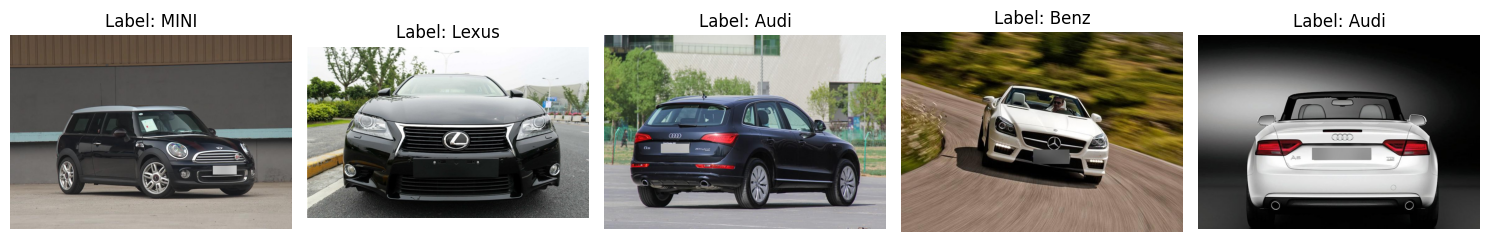

In [55]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select a few random rows from the DataFrame
sample_df = df.sample(n=5, random_state=42) # Select 5 random images for demonstration

# Define the image root directory
image_root_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'

plt.figure(figsize=(15, 5))

for i, (index, row) in enumerate(sample_df.iterrows()):
    image_path = row['image_path']
    train_label = row['make_names']
    full_image_path = os.path.join(image_root_dir, image_path)

    try:
        # Read the image file
        img = Image.open(full_image_path)

        # Display the image
        plt.subplot(1, len(sample_df), i + 1)
        plt.imshow(img)
        plt.title(f"Label: {train_label}")
        plt.axis('off')

    except FileNotFoundError:
        print(f"Error: Image file not found at {full_image_path}")
    except Exception as e:
        print(f"Error reading image {full_image_path}: {e}")

plt.tight_layout()
plt.show()

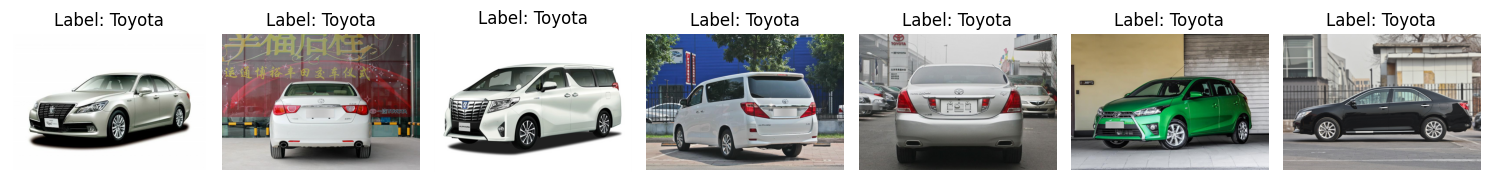

In [56]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Filter the DataFrame for 'Toyota' cars
toyota_df = df[df['make_names'] == 'Toyota']

# Select a few random rows from the filtered DataFrame
# Check if there are enough Toyota cars to sample
if len(toyota_df) > 0:
    sample_toyota_df = toyota_df.sample(n=min(7, len(toyota_df)), random_state=42) # Select up to 5 random images

    # Define the image root directory
    image_root_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'

    plt.figure(figsize=(15, 15))

    for i, (index, row) in enumerate(sample_toyota_df.iterrows()):
        image_path = row['image_path']
        train_label = row['make_names']
        full_image_path = os.path.join(image_root_dir, image_path)

        try:
            # Read the image file
            img = Image.open(full_image_path)

            # Display the image
            plt.subplot(1, len(sample_toyota_df), i + 1)
            plt.imshow(img)
            plt.title(f"Label: {train_label}")
            plt.axis('off')

        except FileNotFoundError:
            print(f"Error: Image file not found at {full_image_path}")
        except Exception as e:
            print(f"Error reading image {full_image_path}: {e}")

    plt.tight_layout()
    plt.show()
else:
    print("No Toyota cars found in the DataFrame.")

**Reasoning**:
Filter the DataFrame to keep only the rows where the `train_label` count is greater than 7.



In [57]:
# Calculate the value counts for the 'train_label' column
train_label_counts = df['make_names'].value_counts()

# Identify the train labels where the count is greater than or equal to k_shot + n_query (5 + 5 = 10)
labels_to_keep = train_label_counts[train_label_counts >= 10].index.tolist()

# Filter the original DataFrame to include only the rows with the identified labels
filtered_df = df[df['make_names'].isin(labels_to_keep)]

# Display the shape of the filtered DataFrame to verify
print(f"Shape of the original DataFrame: {df.shape}")
print(f"Shape of the filtered DataFrame: {filtered_df.shape}")

Shape of the original DataFrame: (9824, 16)
Shape of the filtered DataFrame: (9824, 16)


In [58]:
# Access the 'image_path' column from the filtered_df DataFrame
image_paths = filtered_df['image_path']

# Access the 'train_label' column from the filtered_df DataFrame
labels = filtered_df['make_names']

# Display the first 5 elements of both image_paths and labels
print("First 5 image paths:")
print(image_paths.head())

print("\nFirst 5 labels:")
print(labels.head())

First 5 image paths:
0    78/1/2010/2d7cce791bdd53.jpg
1    78/1/2010/4fb4b93e934b43.jpg
2    78/1/2010/6f64cf12a569dc.jpg
3    78/1/2010/c40f6b80d0cd6e.jpg
4    78/1/2010/5d6ad69be2bd95.jpg
Name: image_path, dtype: object

First 5 labels:
0    Audi
1    Audi
2    Audi
3    Audi
4    Audi
Name: make_names, dtype: object


In [59]:
all_brands_df.shape

(9824, 16)

In [60]:
# Save all_brands_df to CSV
out_dir = "/Users/afrazrupak/CarProject_dev/car_project_dev/data/processed"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "all_brands_with_all_view_point.csv")

all_brands_df.to_csv(out_path, index=False)
print(f"Saved all_brands_df to: {out_path} | shape={all_brands_df.shape}")

Saved all_brands_df to: /Users/afrazrupak/CarProject_dev/car_project_dev/data/processed/all_brands_with_all_view_point.csv | shape=(9824, 16)


In [61]:
raise SystemExit

SystemExit: 

/Users/afrazrupak/tf_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Image Classification Datasets Overview

In [62]:
import os, shutil, random, re
import pandas as pd

# Configuration
# Reuse image_root_dir if already set earlier; otherwise set a default
if 'image_root_dir' not in globals():
    image_root_dir = '/Volumes/Afraz Resource/Vehicle_image_com/image'

output_root = '/Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes_allview'  # change if desired
splits = {'train': 0.8, 'val': 0.1, 'test': 0.1}
copy_mode = 'symlink'  # 'symlink' (fast, saves space on macOS) or 'copy'
min_per_class = 10       # classes must have at least this many images to be included
max_per_class = None     # optionally cap per-class images (e.g., 200); set None to disable
random_seed = 42
random.seed(random_seed)

# Ensure we have a DataFrame named df; if not, load the rear-only CSV
if 'df' not in globals() or df is None or getattr(df, 'empty', True):
    datapath = '/Users/afrazrupak/CarProject_dev/car_project_dev/data/processed/all_brands_with_all_view_point.csv'
    if not os.path.exists(datapath):
        raise FileNotFoundError(f'CSV not found: {datapath}')
    df = pd.read_csv(datapath)

# Build absolute source path for each image and drop missing files
def to_src_path(rel):
    return os.path.join(image_root_dir, rel)

df = df.copy()
df['src_path'] = df['image_path'].apply(to_src_path)
exists_mask = df['src_path'].apply(os.path.exists)
missing = int((~exists_mask).sum())
if missing:
    print(f'[warn] {missing} files not found under image_root_dir; they will be skipped.')
df_exist = df[exists_mask].copy()

# Sanitize label names for folder safety
def sanitize_label(s):
    s = str(s).strip().lower()
    s = s.replace(' ', '_').replace('-', '_').replace('.', '_').replace('/', '_')
    s = re.sub(r'[^a-z0-9_]+', '', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s or 'unknown'

df_exist['class'] = df_exist['make_names'].apply(sanitize_label)

# Keep only classes with enough samples
vc = df_exist['class'].value_counts()
keep_classes = vc[vc >= min_per_class].index.tolist()
df_filt = df_exist[df_exist['class'].isin(keep_classes)].copy()

# Optionally cap per-class count to balance dataset
if max_per_class is not None:
    df_filt = (df_filt.sort_values('class')
               .groupby('class', group_keys=False)
               .apply(lambda g: g.sample(n=min(len(g), max_per_class), random_state=random_seed)))

print(f'Classes kept: {len(keep_classes)} | Images kept: {len(df_filt)}')

# Stratified split per class
def stratified_split_indices(idxs, p_train, p_val, p_test):
    idxs = list(idxs)
    random.shuffle(idxs)
    n = len(idxs)
    n_train = int(round(n * p_train))
    n_val = int(round(n * p_val))
    n_test = n - n_train - n_val
    return idxs[:n_train], idxs[n_train:n_train+n_val], idxs[n_train+n_val:]

df_filt['split'] = ''
for cls, grp in df_filt.groupby('class'):
    ti, vi, si = stratified_split_indices(grp.index, splits['train'], splits['val'], splits['test'])
    df_filt.loc[ti, 'split'] = 'train'
    df_filt.loc[vi, 'split'] = 'val'
    df_filt.loc[si, 'split'] = 'test'

# Create folders
for split in ['train', 'val', 'test']:
    for cls in keep_classes:
        os.makedirs(os.path.join(output_root, split, cls), exist_ok=True)

# Helper to place files
def place_one(src, dst):
    if copy_mode == 'copy':
        shutil.copy2(src, dst)
    else:
        # symlink target relative to destination for portability
        if os.path.lexists(dst):
            os.remove(dst)
        rel_src = os.path.relpath(src, os.path.dirname(dst))
        os.symlink(rel_src, dst)

# Copy/Symlink files into structure
placed = 0; skipped = 0
for i, row in df_filt.iterrows():
    cls = row['class']; split = row['split']; src = row['src_path']
    base = os.path.basename(src)
    # Prefix with row index to reduce collision risk
    dst_name = f'{i}_{base}'
    dst = os.path.join(output_root, split, cls, dst_name)
    try:
        place_one(src, dst)
        placed += 1
    except Exception as e:
        skipped += 1
        print(f'[skip] {src} -> {dst}: {e}')

print(f'Done. Placed: {placed}, Skipped: {skipped}, Root: {output_root}')

# Save class list for reference
label_csv = os.path.join(output_root, 'label_vocabulary.csv')
pd.Series(sorted(keep_classes), name='class').to_csv(label_csv, index=False)
print(f'Wrote labels to: {label_csv}')

Classes kept: 15 | Images kept: 9824
Done. Placed: 9824, Skipped: 0, Root: /Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes_allview
Wrote labels to: /Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes_allview/label_vocabulary.csv


In [64]:
# Verify split counts and show a quick preview of created folders
from collections import Counter
import os

summary = (df_filt.groupby(['split', 'class']).size().unstack(fill_value=0))
print(summary)

for split in ['train', 'val', 'test']:
    n_imgs = int((df_filt['split'] == split).sum())
    n_classes = int((summary.loc[split] > 0).sum()) if split in summary.index else 0
    print(f"{split}: images={n_imgs}, classes={n_classes}")

def preview_tree(root, max_classes=3, max_files=3):
    for split in ['train', 'val', 'test']:
        sdir = os.path.join(root, split)
        print(f'{sdir}')
        if not os.path.exists(sdir):
            continue
        classes = sorted([d for d in os.listdir(sdir) if os.path.isdir(os.path.join(sdir, d))])[:max_classes]
        for c in classes:
            cdir = os.path.join(sdir, c)
            files = sorted(os.listdir(cdir))[:max_files] if os.path.exists(cdir) else []
            print(f'  {c}/ -> {len(os.listdir(cdir)) if os.path.exists(cdir) else 0} files | sample: {files}')

preview_tree(output_root)

class  audi  benz  bmw  byd  ford  honda  hyundai  kia  lexus  mazda  mini  \
split                                                                        
test    101   127  119   49    71     42       59   63     52     51    31   
train   804  1014  958  398   563    335      468  508    415    406   253   
val     100   127  120   50    70     42       58   64     52     51    32   

class  nissan  suzuki  tesla  toyota  
split                                 
test       69      56      3      90  
train     550     443     22     721  
val        69      55      3      90  
train: images=7858, classes=15
val: images=983, classes=15
test: images=983, classes=15
/Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes_allview/train
  audi/ -> 804 files | sample: ['0_2d7cce791bdd53.jpg', '1000_fe520c2c546c56.jpg', '1001_6a90fefd586899.jpg']
  benz/ -> 1014 files | sample: ['1005_26c6f5dbfd6a99.jpg', '1006_b1623545d4112d.jpg', '1008_d2a1ee7648faca.jpg']
  bmw/ -> 958 files 

# YOLO Training
Train the YOLO classification model using the prepared dataset

In [ ]:
# Train YOLO classification model
import subprocess
import os

# Set up paths for your project
yolo_executable = '/Users/afrazrupak/tf_env/bin/yolo'
data_path = '/Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes_allview'
project_path = '/Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify2'

# Ensure the runs directory exists
os.makedirs(project_path, exist_ok=True)

# YOLO training command
cmd = [
    yolo_executable,
    'classify',
    'train',
    f'model=yolo11n-cls.pt',
    f'data={data_path}',
    'epochs=100',
    'imgsz=224',
    f'project={project_path}',
    'name=yolo11n_cls_100e'
]

print('Running YOLO training with command:')
print(' '.join(cmd))
print('\nThis may take a while...')

try:
    # Run the training
    result = subprocess.run(cmd, capture_output=True, text=True, check=True)
    print('\nTraining completed successfully!')
    print('STDOUT:')
    print(result.stdout)
    if result.stderr:
        print('STDERR:')
        print(result.stderr)
except subprocess.CalledProcessError as e:
    print(f'\nTraining failed with error code {e.returncode}')
    print('STDOUT:')
    print(e.stdout)
    print('STDERR:')
    print(e.stderr)
except FileNotFoundError:
    print(f'\nError: YOLO executable not found at {yolo_executable}')
    print('Make sure your tf_env virtual environment is set up correctly and ultralytics is installed.')
    print('You can install it with: pip install ultralytics')

Running YOLO training with command:
/Users/afrazrupak/tf_env/bin/yolo classify train model=yolo11n-cls.pt data=/Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes_allview epochs=100 imgsz=224 project=/Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify2 name=yolo11n_cls_100e

This may take a while...


In [ ]:
# Alternative: Use ultralytics directly (if the subprocess approach doesn't work)
from ultralytics import YOLO

# Initialize model
model = YOLO('yolo11n-cls.pt')

# Train the model
data_path = '/Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes_allview'
project_path = '/Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify2'

results = model.train(
    data=data_path,
    epochs=100,
    imgsz=224,
    project=project_path,
    name='yolo11n_cls_100e'
)

print('Training completed!')
print(f'Results saved to: {results.save_dir}')

New https://pypi.org/project/ultralytics/8.3.200 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.198 🚀 Python-3.11.13 torch-2.8.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11n_cls_

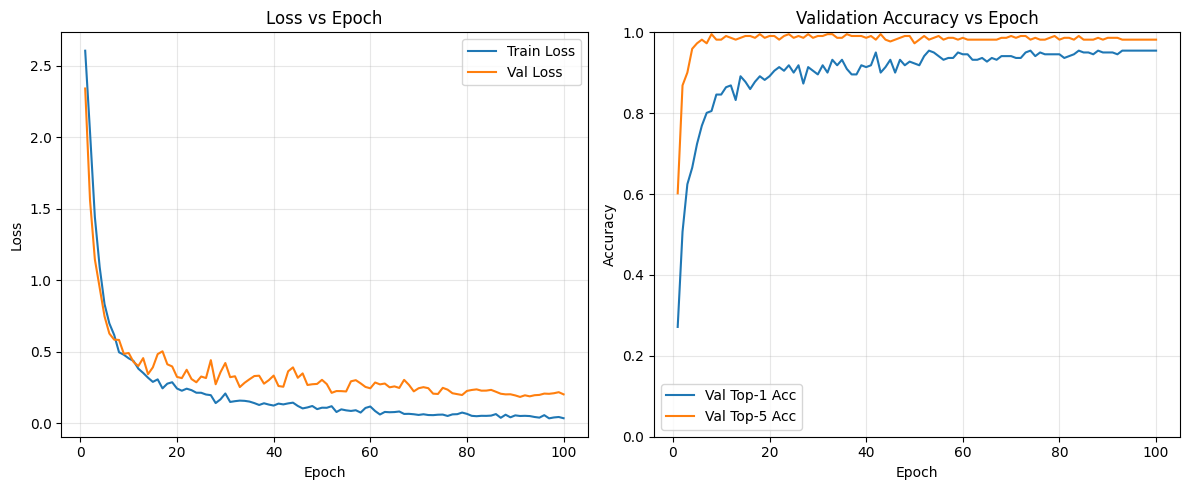

Saved figure to: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e/metrics_overview.png


In [ ]:
# Plot train, validation, and test metrics
import os
import pandas as pd
import matplotlib.pyplot as plt

run_dir = '/Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify2/yolo11n_cls_100e'
results_csv = os.path.join(run_dir, 'results.csv')

if os.path.exists(results_csv):
    df_res = pd.read_csv(results_csv)
    
    epochs = df_res['epoch']
    train_loss = df_res['train/loss']
    val_loss = df_res['val/loss']
    val_top1 = df_res['metrics/accuracy_top1']
    val_top5 = df_res['metrics/accuracy_top5']
    
    # Final metrics
    final_val_top1 = float(val_top1.iloc[-1])
    final_val_top5 = float(val_top5.iloc[-1])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Subplot 1: Loss curves
    axes[0].plot(epochs, train_loss, label='Train Loss')
    axes[0].plot(epochs, val_loss, label='Val Loss')
    axes[0].set_title('Loss vs Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Validation accuracy curves
    axes[1].plot(epochs, val_top1, label='Val Top-1 Acc')
    axes[1].plot(epochs, val_top5, label='Val Top-5 Acc')
    axes[1].set_title('Validation Accuracy vs Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.0, 1.0)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    out_path = os.path.join(run_dir, 'metrics_overview.png')
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'Saved figure to: {out_path}')
else:
    print(f'Results file not found: {results_csv}')
    print('Make sure training has completed successfully.')

# Model Evaluation & Classification Report
Generate detailed performance metrics and classification report

In [ ]:
# Generate classification report and confusion matrix
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from ultralytics import YOLO
from PIL import Image
import glob

# Load the trained model
run_dir = '/Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify2/yolo11n_cls_100e'
model_path = os.path.join(run_dir, 'weights', 'best.pt')

if os.path.exists(model_path):
    model = YOLO(model_path)
    print(f'✓ Model loaded from: {model_path}')
else:
    print(f'❌ Model not found at: {model_path}')
    print('Please ensure training has completed successfully.')

✓ Model loaded from: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e/weights/best.pt


In [ ]:
# Evaluate on test set
test_data_path = '/Users/afrazrupak/CarProject_dev/car_project_dev/yolo_cls_car_makes_allview/test'

if os.path.exists(test_data_path) and os.path.exists(model_path):
    # Get all test images and their true labels
    true_labels = []
    predicted_labels = []
    predicted_probs = []
    image_paths = []
    
    # Get class names from test directory
    class_names = sorted([d for d in os.listdir(test_data_path) 
                         if os.path.isdir(os.path.join(test_data_path, d))])
    
    print(f'Found {len(class_names)} classes: {class_names[:10]}...')
    
    # Process each class directory
    for class_name in class_names:
        class_dir = os.path.join(test_data_path, class_name)
        image_files = glob.glob(os.path.join(class_dir, '*'))
        
        print(f'Processing {class_name}: {len(image_files)} images')
        
        for img_path in image_files:
            try:
                # Predict
                results = model.predict(source=img_path, imgsz=224, verbose=False)
                res = results[0]
                
                # Get prediction
                pred_class_id = int(res.probs.top1)
                pred_class_name = res.names[pred_class_id]
                pred_confidence = float(res.probs.top1conf)
                
                # Store results
                true_labels.append(class_name)
                predicted_labels.append(pred_class_name)
                predicted_probs.append(pred_confidence)
                image_paths.append(img_path)
                
            except Exception as e:
                print(f'Error processing {img_path}: {e}')
                continue
    
    print(f'\nEvaluation completed: {len(true_labels)} images processed')
else:
    print(f'Test data not found at: {test_data_path}')

Found 14 classes: ['audi', 'benz', 'bmw', 'byd', 'ford', 'honda', 'hyundai', 'kia', 'lexus', 'mazda']...
Processing audi: 23 images
Processing benz: 30 images
Processing benz: 30 images
Processing bmw: 29 images
Processing bmw: 29 images
Processing byd: 12 images
Processing byd: 12 images
Processing ford: 14 images
Processing ford: 14 images
Processing honda: 10 images
Processing honda: 10 images
Processing hyundai: 13 images
Processing hyundai: 13 images
Processing kia: 15 images
Processing kia: 15 images
Processing lexus: 11 images
Processing lexus: 11 images
Processing mazda: 11 images
Processing mazda: 11 images
Processing mini: 7 images
Processing mini: 7 images
Processing nissan: 14 images
Processing nissan: 14 images
Processing suzuki: 12 images
Processing suzuki: 12 images
Processing toyota: 20 images
Processing toyota: 20 images

Evaluation completed: 221 images processed

Evaluation completed: 221 images processed


In [ ]:
# Generate classification report
if len(true_labels) > 0:
    # Calculate accuracy
    accuracy = sum(t == p for t, p in zip(true_labels, predicted_labels)) / len(true_labels)
    print(f'Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
    
    # Generate detailed classification report
    report = classification_report(true_labels, predicted_labels, 
                                 target_names=class_names,
                                 output_dict=True)
    
    # Convert to DataFrame for better visualization
    report_df = pd.DataFrame(report).transpose()
    
    # Save classification report
    report_path = os.path.join(run_dir, 'classification_report.csv')
    report_df.to_csv(report_path)
    print(f'\nClassification report saved to: {report_path}')
    
    # Display the report
    print('\n' + '='*50)
    print('CLASSIFICATION REPORT')
    print('='*50)
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
    
    # Show per-class metrics
    print('\nPer-class Performance:')
    print('-'*50)
    class_metrics = report_df.iloc[:-3]  # Exclude macro avg, weighted avg, accuracy
    for idx, row in class_metrics.iterrows():
        print(f'{idx:15} | Precision: {row["precision"]:.3f} | Recall: {row["recall"]:.3f} | F1: {row["f1-score"]:.3f} | Support: {int(row["support"])}')
else:
    print('No predictions available for classification report')

Overall Accuracy: 0.9548 (95.48%)

Classification report saved to: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e/classification_report.csv

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        audi       1.00      1.00      1.00        23
        benz       0.94      1.00      0.97        30
         bmw       0.96      0.93      0.95        29
         byd       1.00      1.00      1.00        12
        ford       1.00      0.93      0.96        14
       honda       1.00      0.90      0.95        10
     hyundai       0.85      0.85      0.85        13
         kia       1.00      1.00      1.00        15
       lexus       0.92      1.00      0.96        11
       mazda       0.91      0.91      0.91        11
        mini       0.88      1.00      0.93         7
      nissan       0.93      0.93      0.93        14
      suzuki       1.00      0.92      0.96        12
      toyota       0.95      0.95      0.95    

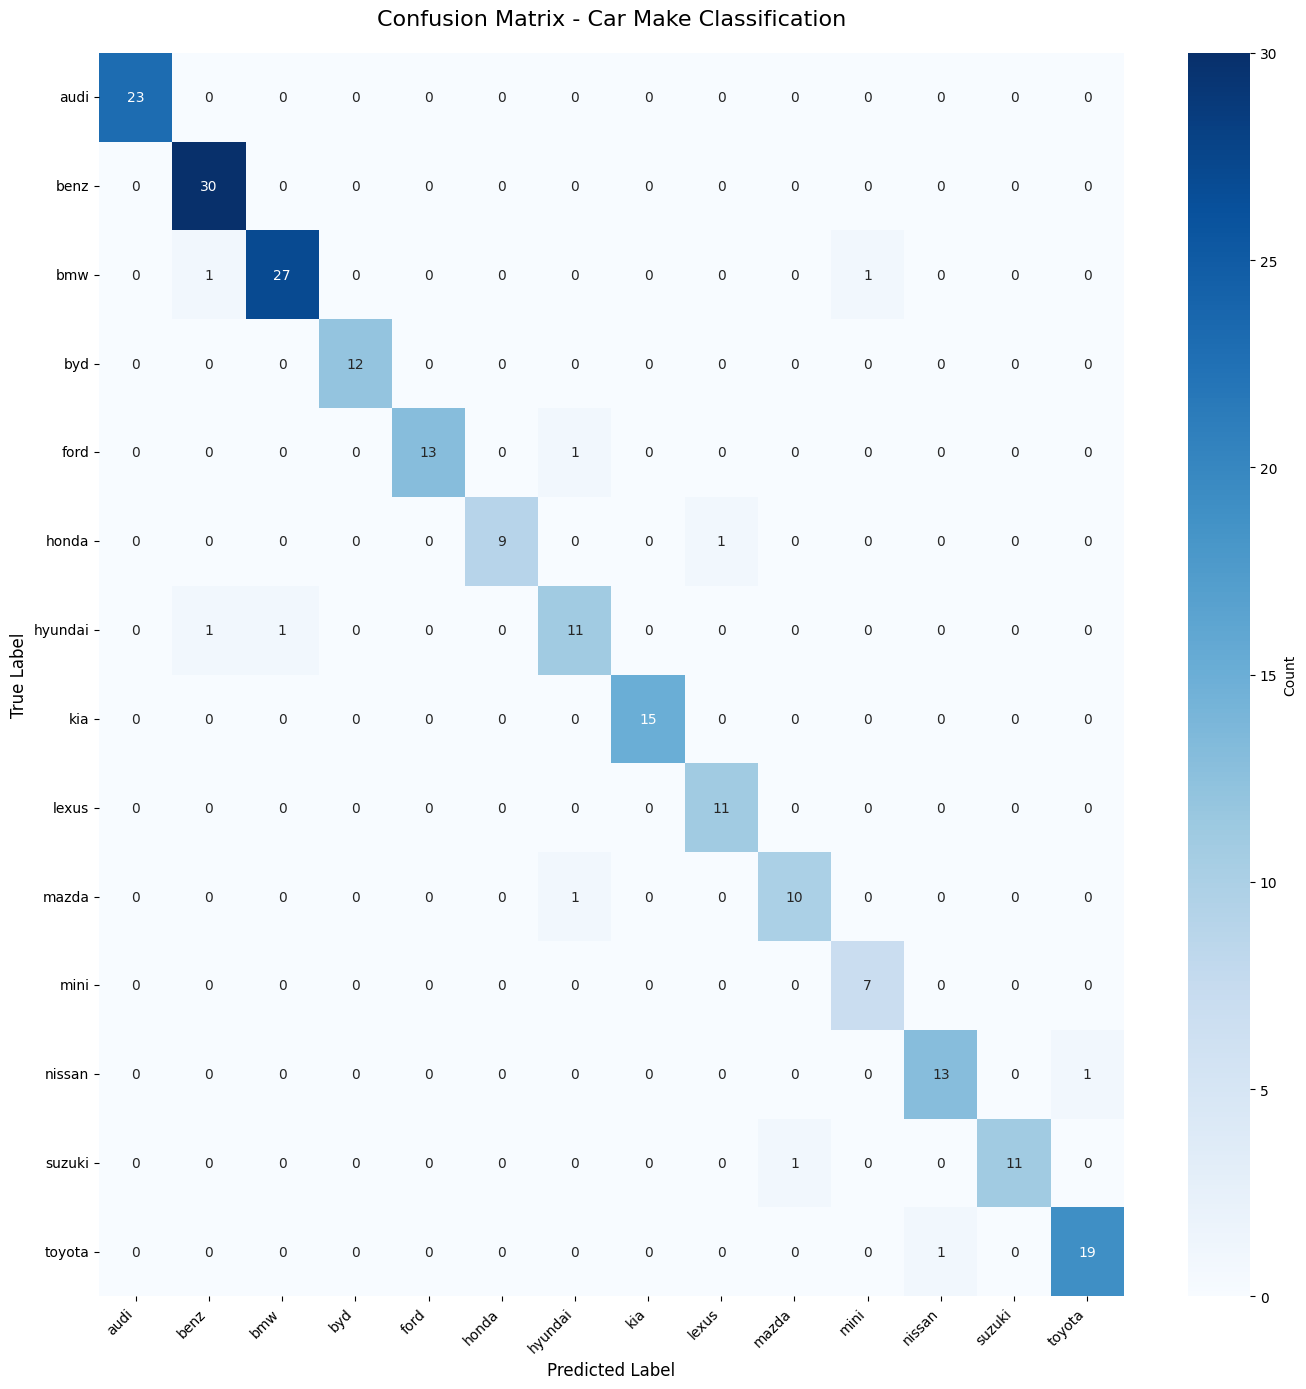

Confusion matrix saved to: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e/confusion_matrix.png


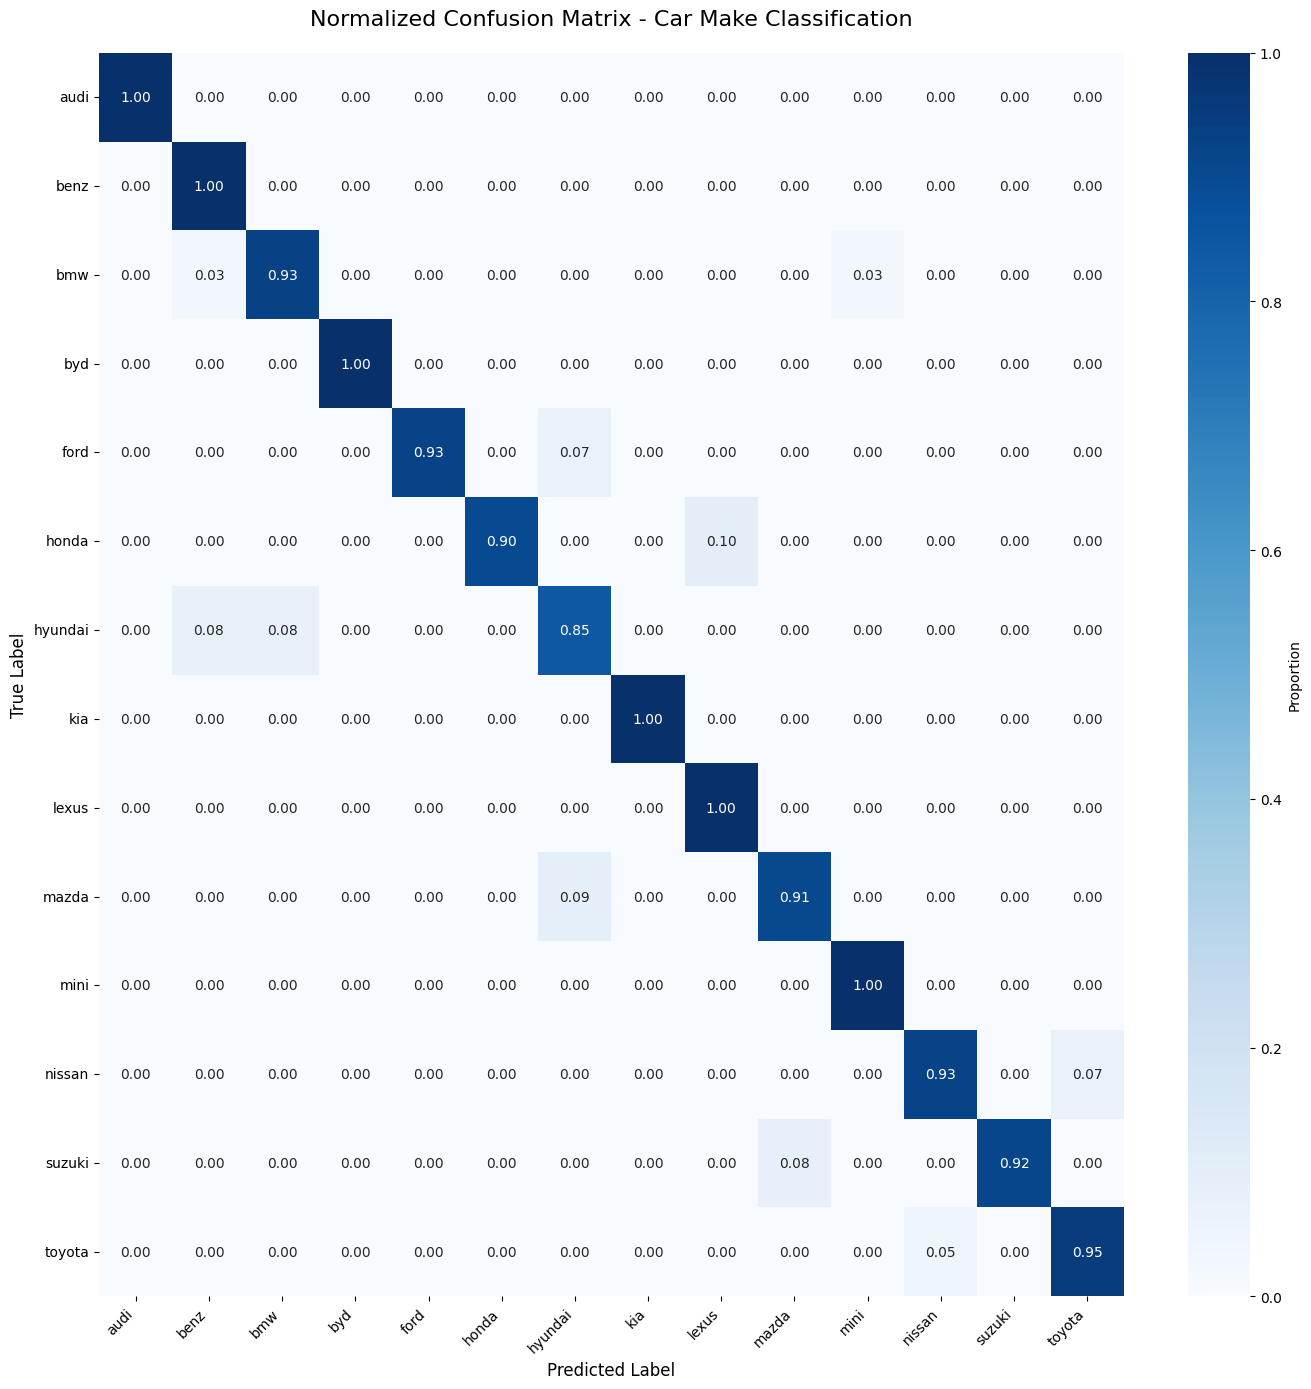

Normalized confusion matrix saved to: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e/confusion_matrix_normalized.png


In [ ]:
# Generate and plot confusion matrix
if len(true_labels) > 0:
    # Calculate confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels, labels=class_names)
    
    # Create figure with appropriate size
    plt.figure(figsize=(max(12, len(class_names)), max(10, len(class_names))))
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    
    plt.title('Confusion Matrix - Car Make Classification', fontsize=16, pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Save confusion matrix
    plt.tight_layout()
    cm_path = os.path.join(run_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix saved to: {cm_path}')
    
    # Calculate and display normalized confusion matrix
    plt.figure(figsize=(max(12, len(class_names)), max(10, len(class_names))))
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proportion'})
    
    plt.title('Normalized Confusion Matrix - Car Make Classification', fontsize=16, pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    cm_norm_path = os.path.join(run_dir, 'confusion_matrix_normalized.png')
    plt.savefig(cm_norm_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Normalized confusion matrix saved to: {cm_norm_path}')


TOP 5 BEST PERFORMING CLASSES (by F1-score)
 1. audi                 | F1: 1.000 | Support:   23
 2. byd                  | F1: 1.000 | Support:   12
 3. kia                  | F1: 1.000 | Support:   15
 4. benz                 | F1: 0.968 | Support:   30
 5. ford                 | F1: 0.963 | Support:   14

TOP 5 WORST PERFORMING CLASSES (by F1-score)
 1. honda                | F1: 0.947 | Support:   10
 2. mini                 | F1: 0.933 | Support:    7
 3. nissan               | F1: 0.929 | Support:   14
 4. mazda                | F1: 0.909 | Support:   11
 5. hyundai              | F1: 0.846 | Support:   13


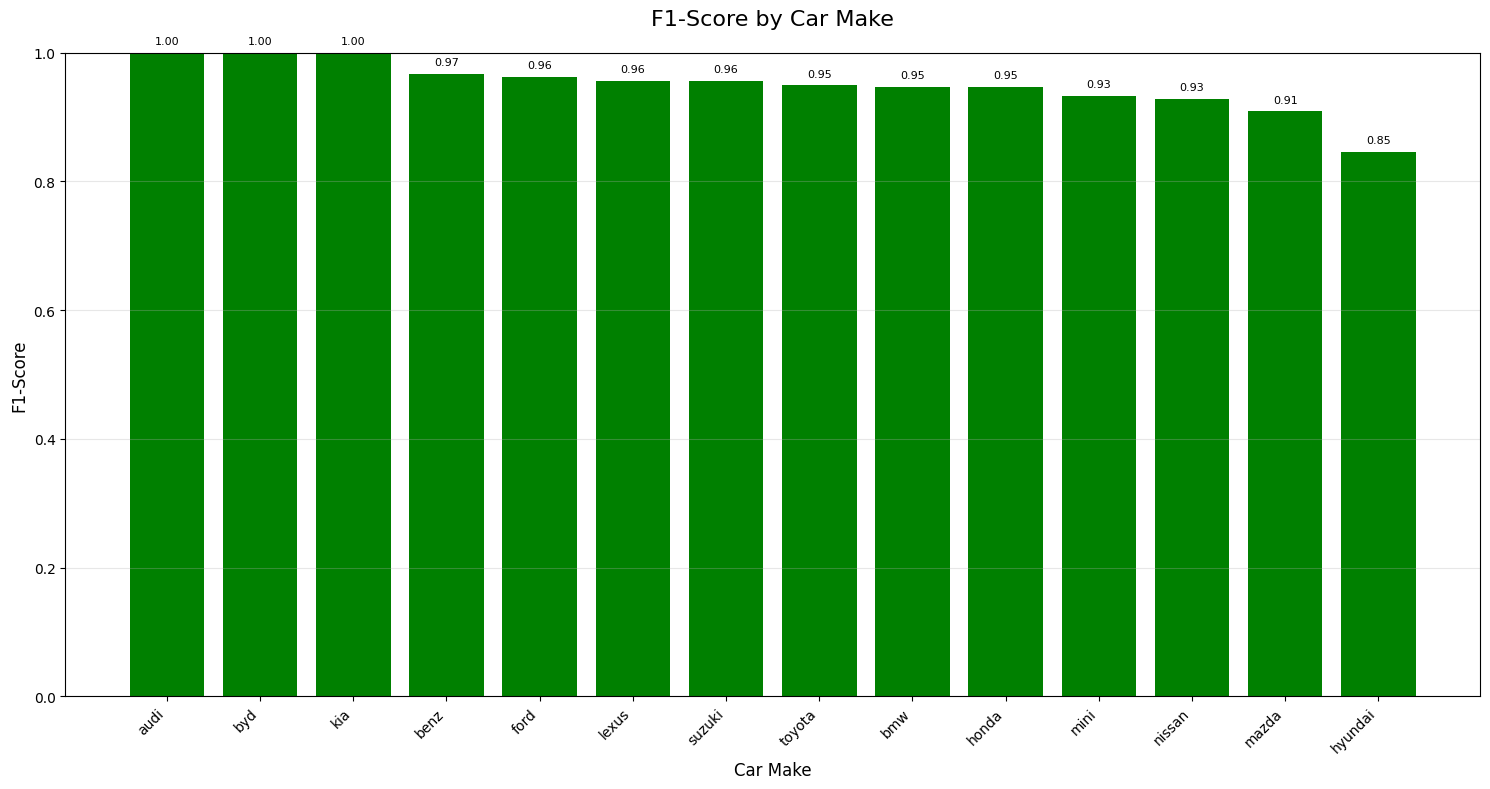


F1-score plot saved to: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e/f1_scores_by_class.png


In [ ]:
# Top/Bottom performing classes analysis
if len(true_labels) > 0:
    # Get per-class F1 scores
    class_f1_scores = []
    for class_name in class_names:
        if class_name in report:
            f1_score = report[class_name]['f1-score']
            support = report[class_name]['support']
            class_f1_scores.append((class_name, f1_score, support))
    
    # Sort by F1 score
    class_f1_scores.sort(key=lambda x: x[1], reverse=True)
    
    print('\n' + '='*60)
    print('TOP 5 BEST PERFORMING CLASSES (by F1-score)')
    print('='*60)
    for i, (class_name, f1, support) in enumerate(class_f1_scores[:5]):
        print(f'{i+1:2d}. {class_name:20} | F1: {f1:.3f} | Support: {int(support):4d}')
    
    print('\n' + '='*60)
    print('TOP 5 WORST PERFORMING CLASSES (by F1-score)')
    print('='*60)
    for i, (class_name, f1, support) in enumerate(class_f1_scores[-5:]):
        print(f'{i+1:2d}. {class_name:20} | F1: {f1:.3f} | Support: {int(support):4d}')
    
    # Plot F1 scores
    plt.figure(figsize=(15, 8))
    classes = [x[0] for x in class_f1_scores]
    f1_scores = [x[1] for x in class_f1_scores]
    
    bars = plt.bar(range(len(classes)), f1_scores, 
                   color=['green' if f1 > 0.8 else 'orange' if f1 > 0.6 else 'red' for f1 in f1_scores])
    
    plt.title('F1-Score by Car Make', fontsize=16, pad=20)
    plt.xlabel('Car Make', fontsize=12)
    plt.ylabel('F1-Score', fontsize=12)
    plt.xticks(range(len(classes)), classes, rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, f1 in zip(bars, f1_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{f1:.2f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    f1_plot_path = os.path.join(run_dir, 'f1_scores_by_class.png')
    plt.savefig(f1_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\nF1-score plot saved to: {f1_plot_path}')

In [ ]:
# Save detailed results to CSV
if len(true_labels) > 0:
    # Create detailed results DataFrame
    results_df = pd.DataFrame({
        'image_path': image_paths,
        'true_label': true_labels,
        'predicted_label': predicted_labels,
        'confidence': predicted_probs,
        'correct': [t == p for t, p in zip(true_labels, predicted_labels)]
    })
    
    # Save detailed results
    detailed_results_path = os.path.join(run_dir, 'detailed_predictions.csv')
    results_df.to_csv(detailed_results_path, index=False)
    print(f'Detailed predictions saved to: {detailed_results_path}')
    
    # Show sample misclassifications
    misclassified = results_df[results_df['correct'] == False]
    if len(misclassified) > 0:
        print(f'\nFound {len(misclassified)} misclassified images')
        print('Sample misclassifications:')
        print(misclassified[['true_label', 'predicted_label', 'confidence']].head(10))
    else:
        print('\nNo misclassifications found - perfect accuracy!')
    
    # Summary statistics
    print(f'\n' + '='*50)
    print('SUMMARY STATISTICS')
    print('='*50)
    print(f'Total images evaluated: {len(results_df)}')
    print(f'Correctly classified: {sum(results_df["correct"])}')
    print(f'Misclassified: {len(results_df) - sum(results_df["correct"])}')
    print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
    print(f'Average confidence: {np.mean(predicted_probs):.3f}')
    print(f'Confidence std: {np.std(predicted_probs):.3f}')
    
    print(f'\n📊 All evaluation results saved to: {run_dir}')

Detailed predictions saved to: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e/detailed_predictions.csv

Found 10 misclassified images
Sample misclassifications:
    true_label predicted_label  confidence
69         bmw            benz    0.998457
77         bmw            mini    0.891428
105       ford         hyundai    0.979587
108      honda           lexus    0.567787
120    hyundai            benz    0.569220
124    hyundai             bmw    0.543041
162      mazda         hyundai    0.796716
178     nissan          toyota    0.506310
195     suzuki           mazda    0.928077
218     toyota          nissan    0.476250

SUMMARY STATISTICS
Total images evaluated: 221
Correctly classified: 211
Misclassified: 10
Accuracy: 0.9548 (95.48%)
Average confidence: 0.974
Confidence std: 0.082

📊 All evaluation results saved to: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e


Top-5 predictions:
  bmw: 1.0000
  honda: 0.0000
  kia: 0.0000
  toyota: 0.0000
  ford: 0.0000


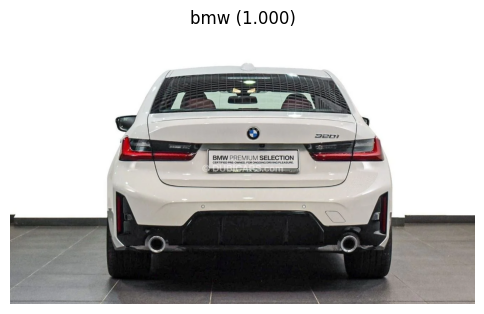

Saved preview to: /Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify/yolo11n_cls_100e/predictions/obmw_pred.png


In [ ]:
# Single-image inference: set image_path to your file and run
import os
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# 1) Put your image path here (absolute path recommended)
image_path = '/Users/afrazrupak/CarProject_dev/car_project_dev/data/test_data/obmw.webp'  # Update this path

# Check if image exists, if not provide instructions
if not os.path.exists(image_path):
    print(f'Test image not found: {image_path}')
    print('Please update the image_path variable above to point to a test image.')
    print('You can use any car image for testing.')
else:
    # 2) Load trained classifier
    run_dir = '/Users/afrazrupak/CarProject_dev/car_project_dev/runs/classify2/yolo11n_cls_100e'
    model_path = os.path.join(run_dir, 'weights', 'best.pt')
    
    if os.path.exists(model_path):
        model = YOLO(model_path)
        
        # 3) Predict
        results = model.predict(source=image_path, imgsz=224, verbose=False)
        res = results[0]
        probs = res.probs
        names = res.names
        top5_ids = [int(i) for i in probs.top5]
        top5_confs = [float(c) for c in probs.top5conf]
        top5_labels = [names[i] for i in top5_ids]
        
        print('Top-5 predictions:')
        for lbl, conf in zip(top5_labels, top5_confs):
            print(f'  {lbl}: {conf:.4f}')
        
        # 4) Show image with top-1 title
        img = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'{top5_labels[0]} ({top5_confs[0]:.3f})')
        
        # Save prediction
        pred_dir = os.path.join(run_dir, 'predictions')
        os.makedirs(pred_dir, exist_ok=True)
        out_path = os.path.join(pred_dir, os.path.basename(image_path).rsplit('.', 1)[0] + '_pred.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved preview to: {out_path}')
    else:
        print(f'Model weights not found: {model_path}')
        print('Make sure training has completed successfully.')